In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.9 MB/s  0:00:00eta 0:00:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("All good")

All good


In [4]:
np.random.seed(42)  # makes our "random" data reproducible every time

skus = {
    'MW-STR-DRK-28': ('Straight', 'Dark',    'Core',    138),
    'MW-STR-MED-28': ('Straight', 'Medium',  'Core',    128),
    'MW-STR-LGT-28': ('Straight', 'Light',   'Core',    118),
    'MW-SKN-DRK-26': ('Skinny',   'Dark',    'Core',    118),
    'MW-SKN-MED-26': ('Skinny',   'Medium',  'Core',    108),
    'MW-SKN-BLK-26': ('Skinny',   'Black',   'Core',    128),
    'MW-WLD-DRK-29': ('Wide-Leg', 'Dark',    'Trend',   148),
    'MW-WLD-LGT-29': ('Wide-Leg', 'Light',   'Trend',   148),
    'MW-WLD-MED-29': ('Wide-Leg', 'Medium',  'Trend',   138),
    'MW-FLR-DRK-28': ('Flare',    'Dark',    'Trend',   158),
    'MW-FLR-LGT-28': ('Flare',    'Light',   'Trend',   158),
    'MW-BFR-MED-30': ('Boyfriend','Medium',  'Relaxed', 138),
    'MW-BFR-LGT-30': ('Boyfriend','Light',   'Relaxed', 128),
    'MW-BFR-DRK-30': ('Boyfriend','Dark',    'Relaxed', 138),
    'MW-STR-BLK-28': ('Straight', 'Black',   'Core',    128),
    'MW-SKN-LGT-26': ('Skinny',   'Light',   'Core',    108),
    'MW-WLD-BLK-29': ('Wide-Leg', 'Black',   'Trend',   158),
    'MW-FLR-MED-28': ('Flare',    'Medium',  'Trend',   148),
    'MW-BFR-BLK-30': ('Boyfriend','Black',   'Relaxed', 148),
    'MW-FLR-BLK-28': ('Flare',    'Black',   'Trend',   168),
}

sku_df = pd.DataFrame.from_dict(
    skus, orient='index',
    columns=['Silhouette', 'Wash', 'Category', 'Price_USD']
).reset_index().rename(columns={'index': 'SKU_ID'})

print(f"{len(sku_df)} SKUs loaded")
sku_df.head()

20 SKUs loaded


,SKU_ID,Silhouette,Wash,Category,Price_USD
0,MW-STR-DRK-28,Straight,Dark,Core,138
1,MW-STR-MED-28,Straight,Medium,Core,128
2,MW-STR-LGT-28,Straight,Light,Core,118
3,MW-SKN-DRK-26,Skinny,Dark,Core,118
4,MW-SKN-MED-26,Skinny,Medium,Core,108


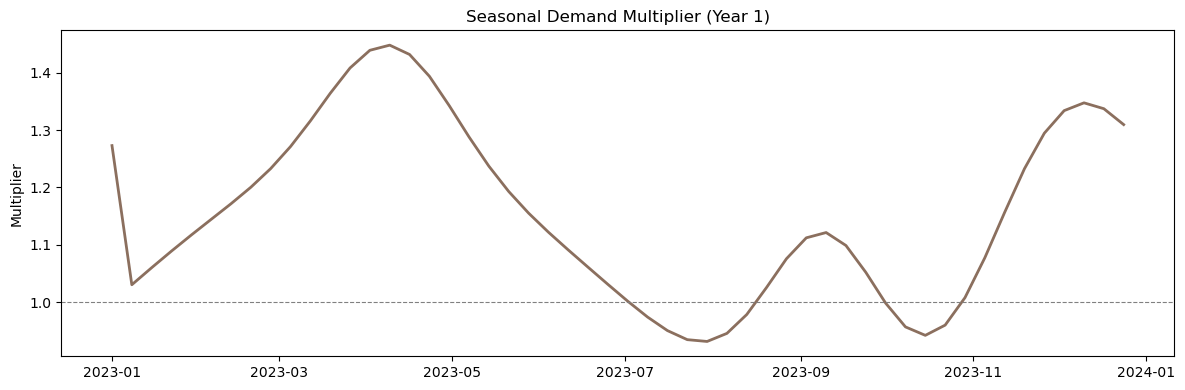

Weeks generated: 105


In [5]:
dates = pd.date_range('2023-01-01', '2024-12-29', freq='W-SUN')
week_of_year = dates.isocalendar().week.values.astype(float)

seasonal = (
    1.0
    + 0.25 * np.sin(2 * np.pi * week_of_year / 52)           # general summer bump
    + 0.35 * np.exp(-0.5 * ((week_of_year - 36) / 3) ** 2)  # back-to-school (week 36)
    + 0.45 * np.exp(-0.5 * ((week_of_year - 48) / 4) ** 2)  # holiday (week 48)
    + 0.20 * np.exp(-0.5 * ((week_of_year - 14) / 3) ** 2)  # spring refresh (week 14)
)

# Quick visual check
plt.figure(figsize=(12, 4))
plt.plot(dates[:52], seasonal[:52], color='#8B6F5E', linewidth=2)
plt.title('Seasonal Demand Multiplier (Year 1)')
plt.ylabel('Multiplier')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Weeks generated: {len(dates)}")

In [8]:
# Recalculate demand flags with corrected thresholds
df['Weeks_of_Supply'] = df['Ending_Stock'] / df['Demand'].replace(0, 0.1)
avg_demand = df.groupby('SKU_ID')['Demand'].transform('mean')

df['Markdown_Risk'] = (
    (df['Weeks_of_Supply'] > 6) & (df['Demand'] < avg_demand * 0.9)
).astype(int)

print(f"Stockout weeks:      {df['Stockout'].sum()}")
print(f"Markdown risk weeks: {df['Markdown_Risk'].sum()}")
print(f"Stockout rate:       {df['Stockout'].mean():.1%}")
print(f"Markdown rate:       {df['Markdown_Risk'].mean():.1%}")

Stockout weeks:      559
Markdown risk weeks: 39
Stockout rate:       26.6%
Markdown rate:       1.9%


In [9]:
df['Markdown_Risk'] = (
    (df['Weeks_of_Supply'] > 4) & (df['Demand'] < avg_demand * 0.95)
).astype(int)

print(f"Stockout weeks:      {df['Stockout'].sum()}")
print(f"Markdown risk weeks: {df['Markdown_Risk'].sum()}")
print(f"Stockout rate:       {df['Stockout'].mean():.1%}")
print(f"Markdown rate:       {df['Markdown_Risk'].mean():.1%}")

Stockout weeks:      559
Markdown risk weeks: 246
Stockout rate:       26.6%
Markdown rate:       11.7%


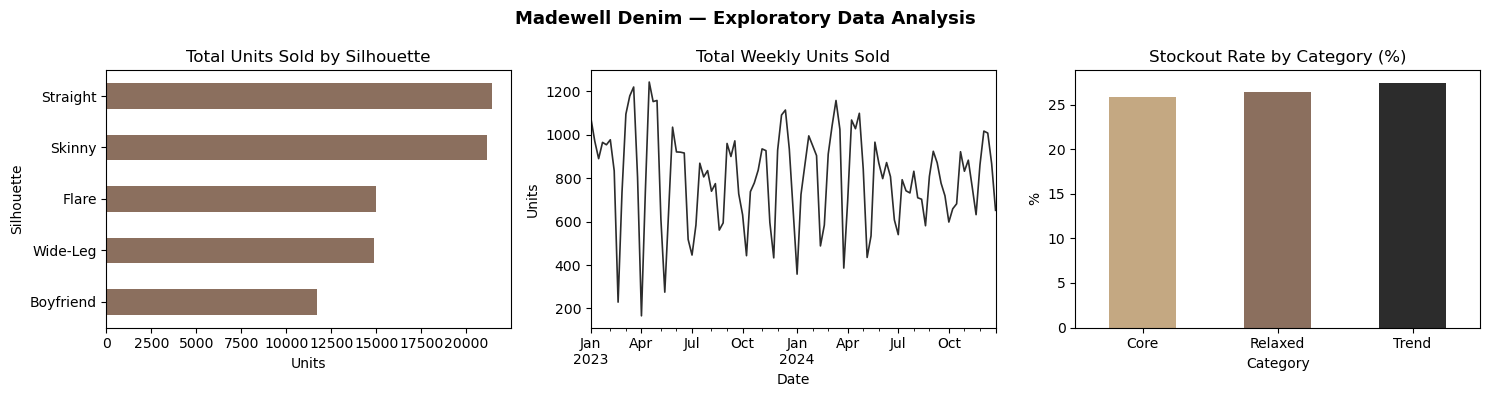

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Total units sold by silhouette
df.groupby('Silhouette')['Units_Sold'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color='#8B6F5E'
)
axes[0].set_title('Total Units Sold by Silhouette')
axes[0].set_xlabel('Units')

# 2. Weekly demand over time (all SKUs combined)
df.groupby('Date')['Units_Sold'].sum().plot(
    ax=axes[1], color='#2C2C2C', linewidth=1.2
)
axes[1].set_title('Total Weekly Units Sold')
axes[1].set_ylabel('Units')

# 3. Stockout rate by category
df.groupby('Category')['Stockout'].mean().mul(100).plot(
    kind='bar', ax=axes[2], color=['#C4A882', '#8B6F5E', '#2C2C2C'], rot=0
)
axes[2].set_title('Stockout Rate by Category (%)')
axes[2].set_ylabel('%')

plt.suptitle('Madewell Denim — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Find the top 6 SKUs by total units sold
top_skus = (df.groupby('SKU_ID')['Units_Sold']
              .sum()
              .sort_values(ascending=False)
              .head(6)
              .index
              .tolist())

print("Top 6 SKUs by volume:")
for sku in top_skus:
    total = df[df['SKU_ID'] == sku]['Units_Sold'].sum()
    print(f"  {sku}: {total:,} units")


Top 6 SKUs by volume:
  MW-SKN-MED-26: 5,390 units
  MW-STR-DRK-28: 5,390 units
  MW-STR-BLK-28: 5,390 units
  MW-STR-MED-28: 5,370 units
  MW-SKN-BLK-26: 5,349 units
  MW-SKN-DRK-26: 5,307 units


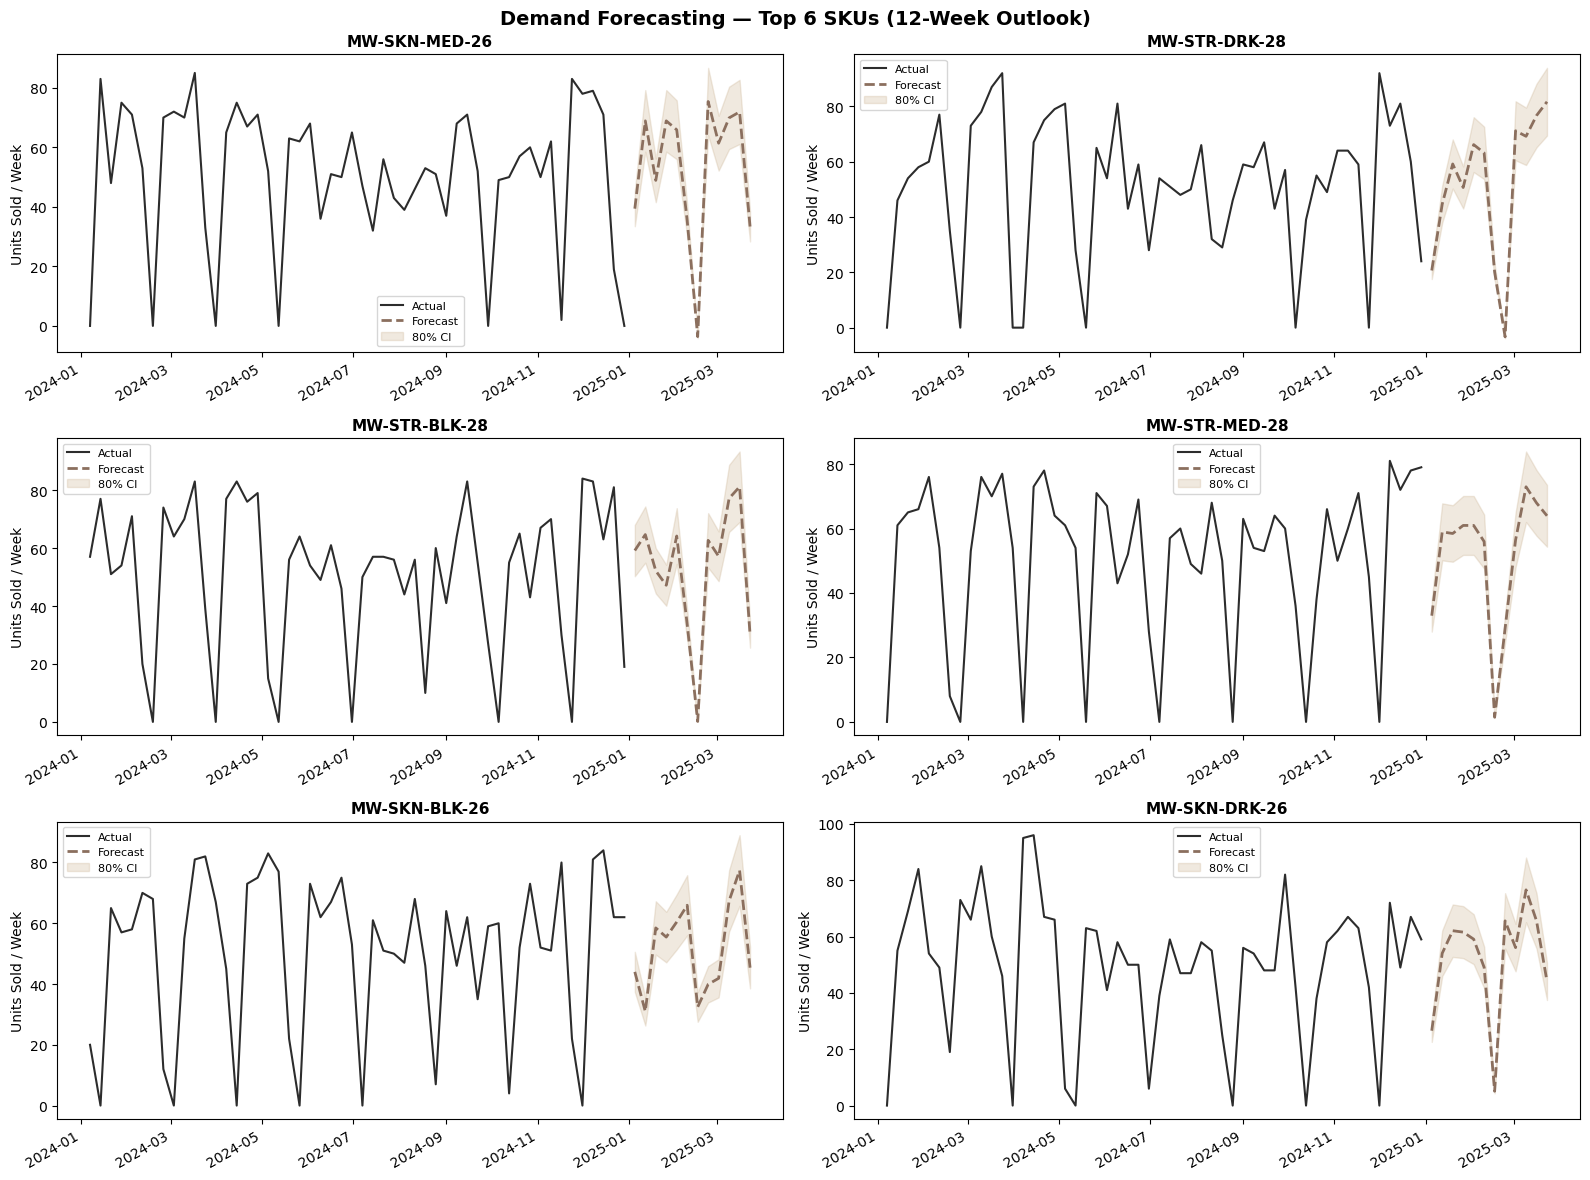

Forecasts generated: 72 rows


,SKU_ID,Date,Forecast,CI_Lower,CI_Upper
0,MW-SKN-MED-26,2025-01-05,39.4,33.5,45.3
1,MW-SKN-MED-26,2025-01-12,68.9,58.6,79.2
2,MW-SKN-MED-26,2025-01-19,48.9,41.6,56.2
3,MW-SKN-MED-26,2025-01-26,68.9,58.6,79.2
4,MW-SKN-MED-26,2025-02-02,65.9,56.0,75.8


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()  # makes it easier to loop through

forecast_records = []

for i, sku in enumerate(top_skus):
    # Get this SKU's weekly sales as a time series
    sku_data = df[df['SKU_ID'] == sku].set_index('Date')['Units_Sold']

    # Fit the Holt-Winters model
    # trend='add' means we expect a linear trend (up or down)
    # seasonal='add' means seasonality adds on top of trend
    # seasonal_periods=52 means we expect a yearly seasonal cycle
    model = ExponentialSmoothing(
        sku_data,
        trend='add',
        seasonal='add',
        seasonal_periods=52,
        initialization_method='estimated'
    )
    fit = model.fit(optimized=True, remove_bias=True)

    # Generate 12 weeks of future forecasts
    forecast = fit.forecast(12)
    forecast_dates = pd.date_range(
        sku_data.index[-1] + pd.Timedelta(weeks=1),
        periods=12,
        freq='W-SUN'
    )

    # Rough confidence interval: +/- 15%
    ci_upper = forecast * 1.15
    ci_lower = (forecast * 0.85).clip(0)

    # Save forecast data for later use
    for d, f, lo, hi in zip(forecast_dates, forecast, ci_lower, ci_upper):
        forecast_records.append({
            'SKU_ID': sku,
            'Date': d,
            'Forecast': round(f, 1),
            'CI_Lower': round(lo, 1),
            'CI_Upper': round(hi, 1)
        })

    # Plot: last 52 weeks of actuals + 12-week forecast
    ax = axes[i]
    last_year = sku_data.iloc[-52:]
    ax.plot(last_year.index, last_year.values,
            color='#2C2C2C', lw=1.5, label='Actual')
    ax.plot(forecast_dates, forecast.values,
            color='#8B6F5E', lw=2, linestyle='--', label='Forecast')
    ax.fill_between(forecast_dates, ci_lower, ci_upper,
                    alpha=0.25, color='#C4A882', label='80% CI')

    ax.set_title(sku, fontsize=11, fontweight='bold')
    ax.set_ylabel('Units Sold / Week')
    ax.legend(fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Demand Forecasting — Top 6 SKUs (12-Week Outlook)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame(forecast_records)
print(f"Forecasts generated: {forecast_df.shape[0]} rows")
forecast_df.head()

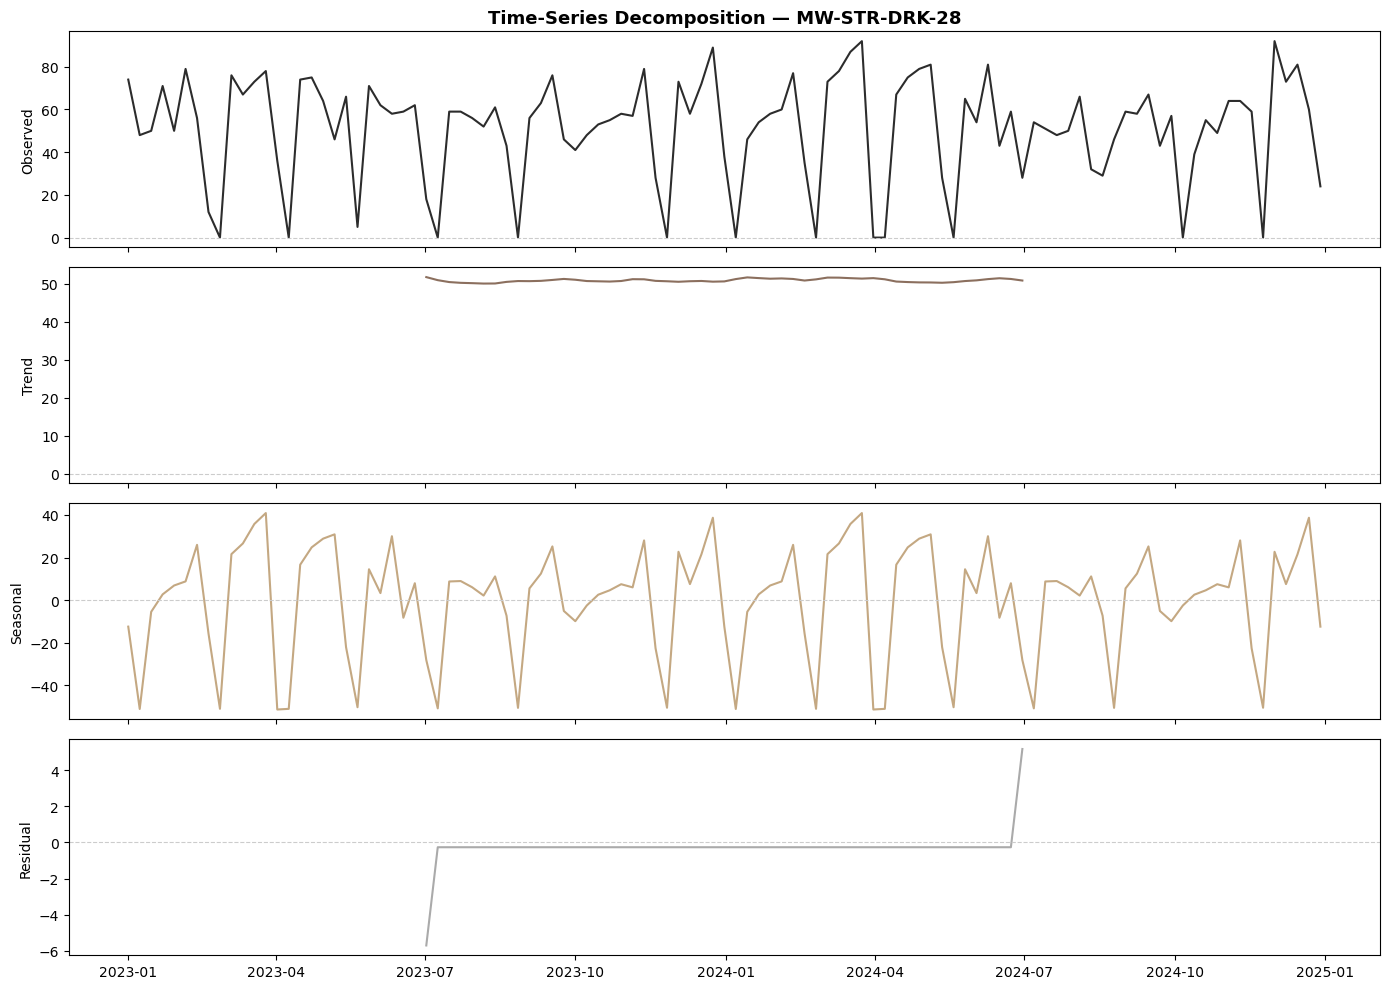

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

hero = 'MW-STR-DRK-28'
hero_series = df[df['SKU_ID'] == hero].set_index('Date')['Units_Sold']

decomp = seasonal_decompose(hero_series, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = [
    ('Observed',  hero_series,     '#2C2C2C'),
    ('Trend',     decomp.trend,    '#8B6F5E'),
    ('Seasonal',  decomp.seasonal, '#C4A882'),
    ('Residual',  decomp.resid,    '#aaaaaa'),
]

for ax, (label, data, color) in zip(axes, components):
    ax.plot(data, color=color, lw=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.axhline(0, color='#cccccc', lw=0.8, linestyle='--')

axes[0].set_title(f'Time-Series Decomposition — {hero}',
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

feature_df = df.copy()
feature_df = feature_df.sort_values(['SKU_ID', 'Date'])

# Lag features: what did demand look like in previous weeks?
for lag in [1, 2, 4]:
    feature_df[f'Demand_Lag{lag}'] = feature_df.groupby('SKU_ID')['Demand'].shift(lag)

# Rolling average: smoothed demand signal
feature_df['Demand_4W_MA'] = feature_df.groupby('SKU_ID')['Demand'].transform(
    lambda x: x.shift(1).rolling(4).mean())

# Demand trend: is demand rising or falling recently?
feature_df['Demand_Trend'] = feature_df.groupby('SKU_ID')['Demand'].transform(
    lambda x: x.shift(1).rolling(8).mean() - x.shift(5).rolling(4).mean())

# How fast is stock moving relative to what's on hand?
feature_df['Stock_Velocity'] = feature_df['Units_Sold'] / feature_df['Ending_Stock'].replace(0, 0.01)

# Encode categorical columns as numbers (ML models need numbers)
le = LabelEncoder()
feature_df['Silhouette_Enc'] = le.fit_transform(feature_df['Silhouette'])
feature_df['Wash_Enc']       = le.fit_transform(feature_df['Wash'])
feature_df['Category_Enc']   = le.fit_transform(feature_df['Category'])

print(f"Feature dataframe shape: {feature_df.shape}")
feature_df.head()

Feature dataframe shape: (2100, 24)


,SKU_ID,Date,Week,Demand,Units_Sold,Ending_Stock,Stockout,Silhouette,Wash,Category,...,Markdown_Risk,Demand_Lag1,Demand_Lag2,Demand_Lag4,Demand_4W_MA,Demand_Trend,Stock_Velocity,Silhouette_Enc,Wash_Enc,Category_Enc
1890,MW-BFR-BLK-30,2023-01-01,1,29,29,211,0,Boyfriend,Black,Relaxed,...,1,NaN,NaN,NaN,NaN,NaN,0.137441,0,0,1
1891,MW-BFR-BLK-30,2023-01-08,2,28,28,183,0,Boyfriend,Black,Relaxed,...,1,29.0,NaN,NaN,NaN,NaN,0.153005,0,0,1
1892,MW-BFR-BLK-30,2023-01-15,3,21,21,162,0,Boyfriend,Black,Relaxed,...,1,28.0,29.0,NaN,NaN,NaN,0.129630,0,0,1
1893,MW-BFR-BLK-30,2023-01-22,4,37,37,125,0,Boyfriend,Black,Relaxed,...,0,21.0,28.0,NaN,NaN,NaN,0.296000,0,0,1
1894,MW-BFR-BLK-30,2023-01-29,5,22,22,103,0,Boyfriend,Black,Relaxed,...,1,37.0,21.0,29.0,28.75,NaN,0.213592,0,0,1


In [15]:
FEATURES = [
    'Demand', 'Demand_Lag1', 'Demand_Lag2', 'Demand_Lag4',
    'Demand_4W_MA', 'Demand_Trend', 'Weeks_of_Supply',
    'Stock_Velocity', 'Ending_Stock', 'Price_USD',
    'Silhouette_Enc', 'Wash_Enc', 'Category_Enc',
    'Month', 'Quarter', 'Week'
]

# Drop rows where lag features are NaN
model_df = feature_df.dropna(subset=FEATURES)

X = model_df[FEATURES]
y_markdown = model_df['Markdown_Risk']

# 80% train, 20% test
X_train, X_test, ym_train, ym_test = train_test_split(
    X, y_markdown, test_size=0.2, random_state=42, stratify=y_markdown
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")
print(f"Markdown positives in train: {ym_train.sum()} ({ym_train.mean():.1%})")
print(f"Markdown positives in test:  {ym_test.sum()} ({ym_test.mean():.1%})")

Training rows: 1552
Test rows:     388
Markdown positives in train: 174 (11.2%)
Markdown positives in test:  44 (11.3%)


In [16]:
md_model = XGBClassifier(
    n_estimators=200,        # number of trees
    max_depth=5,             # how deep each tree can grow
    learning_rate=0.08,      # how much each tree corrects the previous one
    subsample=0.8,           # use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,    # use 80% of features per tree (reduces overfitting)
    scale_pos_weight=(ym_train == 0).sum() / (ym_train == 1).sum(),
    # ^ this tells the model to weight the minority class (markdown=1)
    # more heavily, since only 11% of rows are positive
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

md_model.fit(X_train, ym_train)

ym_pred = md_model.predict(X_test)
ym_prob = md_model.predict_proba(X_test)[:, 1]

print(classification_report(
    ym_test, ym_pred,
    labels=[0, 1],
    target_names=['No Risk', 'Markdown Risk'],
    zero_division=0
))
print(f"ROC-AUC: {roc_auc_score(ym_test, ym_prob):.4f}")

               precision    recall  f1-score   support

      No Risk       1.00      0.99      1.00       344
Markdown Risk       0.96      0.98      0.97        44

     accuracy                           0.99       388
    macro avg       0.98      0.99      0.98       388
 weighted avg       0.99      0.99      0.99       388

ROC-AUC: 0.9998


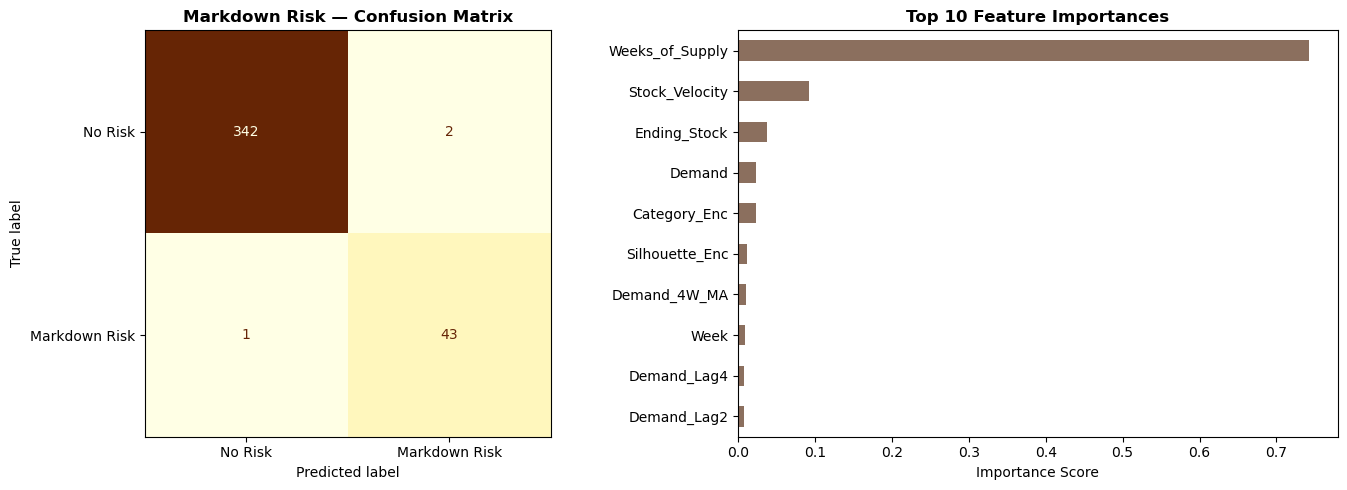

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(ym_test, ym_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Risk', 'Markdown Risk'])
disp.plot(ax=axes[0], colorbar=False, cmap='YlOrBr')
axes[0].set_title('Markdown Risk — Confusion Matrix', fontweight='bold')

# Feature importance
fi = pd.Series(md_model.feature_importances_, index=FEATURES).sort_values()
fi.tail(10).plot(kind='barh', ax=axes[1], color='#8B6F5E')
axes[1].set_title('Top 10 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [18]:
y_stockout = model_df['Stockout']

X_train, X_test, ys_train, ys_test = train_test_split(
    X, y_stockout, test_size=0.2, random_state=42, stratify=y_stockout
)

so_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(ys_train == 0).sum() / (ys_train == 1).sum(),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

so_model.fit(X_train, ys_train)

ys_pred = so_model.predict(X_test)
ys_prob = so_model.predict_proba(X_test)[:, 1]

print(classification_report(
    ys_test, ys_pred,
    labels=[0, 1],
    target_names=['No Stockout', 'Stockout'],
    zero_division=0
))
print(f"ROC-AUC: {roc_auc_score(ys_test, ys_prob):.4f}")

              precision    recall  f1-score   support

 No Stockout       1.00      1.00      1.00       281
    Stockout       1.00      1.00      1.00       107

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388

ROC-AUC: 1.0000


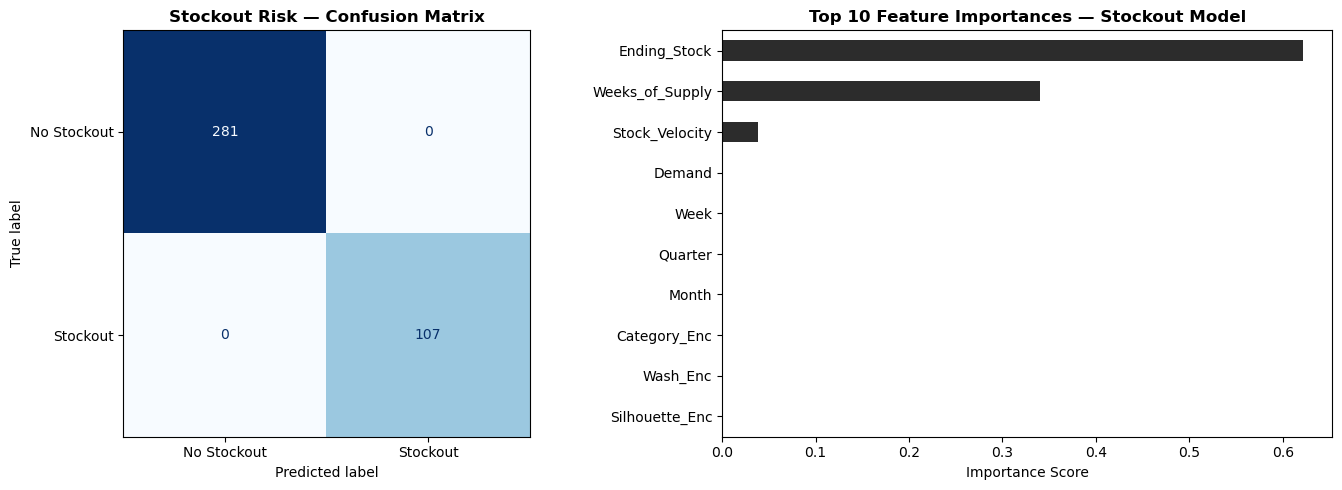

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm2 = confusion_matrix(ys_test, ys_pred, labels=[0, 1])
disp2 = ConfusionMatrixDisplay(cm2, display_labels=['No Stockout', 'Stockout'])
disp2.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Stockout Risk — Confusion Matrix', fontweight='bold')

fi2 = pd.Series(so_model.feature_importances_, index=FEATURES).sort_values()
fi2.tail(10).plot(kind='barh', ax=axes[1], color='#2C2C2C')
axes[1].set_title('Top 10 Feature Importances — Stockout Model', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [20]:
ORDERING_COST  = 35    # $ per purchase order placed
HOLDING_RATE   = 0.20  # annual holding cost = 20% of unit cost
LEAD_TIME_WEEKS = 4    # weeks between placing and receiving an order
SERVICE_LEVEL_Z = 1.65 # Z-score for 95% service level

# Aggregate stats per SKU
sku_stats = (df.groupby(['SKU_ID', 'Silhouette', 'Wash', 'Category', 'Price_USD'])
               .agg(
                   Avg_Weekly_Demand=('Demand', 'mean'),
                   Std_Weekly_Demand=('Demand', 'std'),
                   Total_Units_Sold=('Units_Sold', 'sum'),
                   Stockout_Weeks=('Stockout', 'sum'),
                   Markdown_Weeks=('Markdown_Risk', 'sum'),
               ).reset_index())

# EOQ formula
sku_stats['Annual_Demand'] = sku_stats['Avg_Weekly_Demand'] * 52
sku_stats['Holding_Cost']  = sku_stats['Price_USD'] * 0.55 * HOLDING_RATE
sku_stats['EOQ'] = np.sqrt(
    2 * sku_stats['Annual_Demand'] * ORDERING_COST / sku_stats['Holding_Cost']
).round(0).astype(int)

# Safety stock: buffer against demand spikes
sku_stats['Safety_Stock'] = (
    SERVICE_LEVEL_Z * sku_stats['Std_Weekly_Demand'] * np.sqrt(LEAD_TIME_WEEKS)
).round(0).astype(int)

# Reorder point: trigger a new order when stock hits this level
sku_stats['Reorder_Point'] = (
    sku_stats['Avg_Weekly_Demand'] * LEAD_TIME_WEEKS + sku_stats['Safety_Stock']
).round(0).astype(int)

# Risk tier for each SKU
sku_stats['Stockout_Rate_Pct']  = (sku_stats['Stockout_Weeks']  / 105 * 100).round(1)
sku_stats['Markdown_Rate_Pct']  = (sku_stats['Markdown_Weeks']  / 105 * 100).round(1)

def risk_tier(row):
    if row['Stockout_Rate_Pct'] > 10:  return 'High Stockout Risk'
    if row['Markdown_Rate_Pct'] > 15:  return 'Markdown Risk'
    return 'Healthy'

sku_stats['Risk_Tier'] = sku_stats.apply(risk_tier, axis=1)

cols = ['SKU_ID', 'Category', 'Price_USD', 'Avg_Weekly_Demand',
        'EOQ', 'Safety_Stock', 'Reorder_Point',
        'Stockout_Rate_Pct', 'Markdown_Rate_Pct', 'Risk_Tier']
print(f"SKUs analyzed: {len(sku_stats)}")
sku_stats[cols].round(1)

SKUs analyzed: 20


,SKU_ID,Category,Price_USD,Avg_Weekly_Demand,EOQ,Safety_Stock,Reorder_Point,Stockout_Rate_Pct,Markdown_Rate_Pct,Risk_Tier
0,MW-BFR-BLK-30,Relaxed,148,34.1,87,25,161,26.7,17.1,High Stockout Risk
1,MW-BFR-DRK-30,Relaxed,138,34.7,91,25,164,24.8,12.4,High Stockout Risk
2,MW-BFR-LGT-30,Relaxed,128,35.2,95,27,168,26.7,15.2,High Stockout Risk
3,MW-BFR-MED-30,Relaxed,138,35.2,92,24,165,27.6,15.2,High Stockout Risk
4,MW-FLR-BLK-28,Trend,168,45.2,94,28,209,25.7,11.4,High Stockout Risk
5,MW-FLR-DRK-28,Trend,158,45.4,98,27,209,27.6,8.6,High Stockout Risk
6,MW-FLR-LGT-28,Trend,158,45.5,98,32,214,29.5,11.4,High Stockout Risk
7,MW-FLR-MED-28,Trend,148,46.5,102,32,218,29.5,11.4,High Stockout Risk
8,MW-SKN-BLK-26,Core,128,63.5,128,40,294,25.7,8.6,High Stockout Risk
9,MW-SKN-DRK-26,Core,118,62.8,133,41,292,24.8,12.4,High Stockout Risk


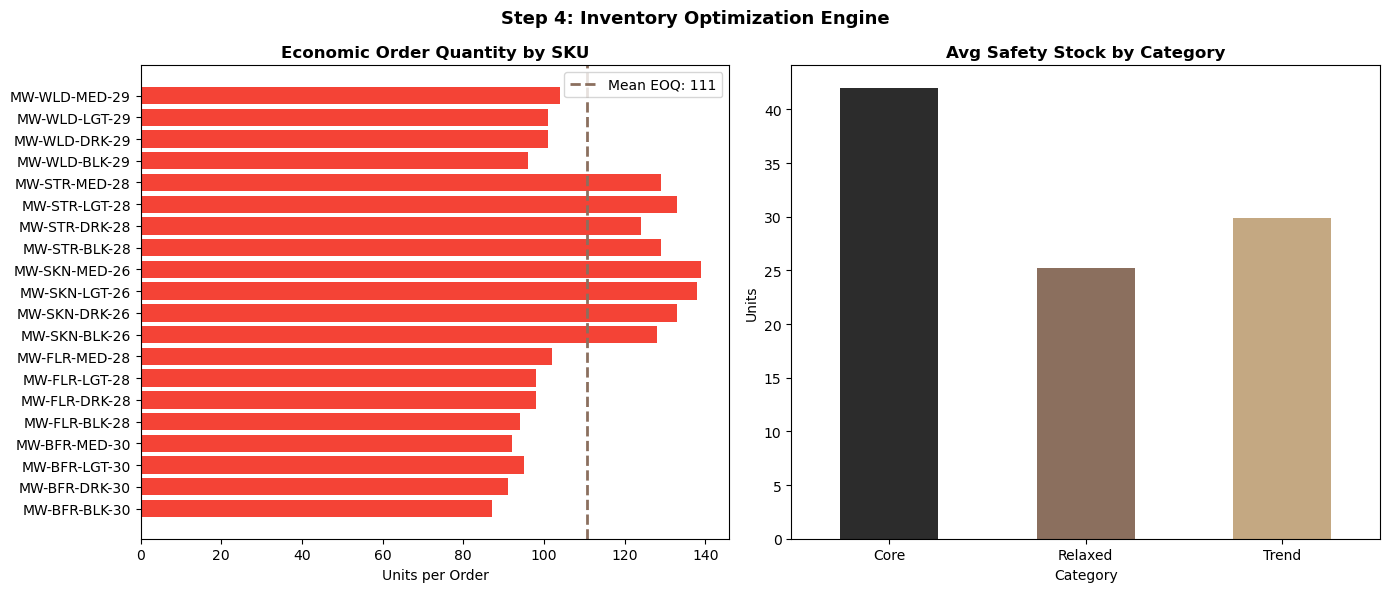

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# EOQ by SKU colored by risk
colors = ['#F44336' if t == 'High Stockout Risk'
          else '#FFC107' if t == 'Markdown Risk'
          else '#4CAF50'
          for t in sku_stats['Risk_Tier']]

axes[0].barh(sku_stats['SKU_ID'], sku_stats['EOQ'], color=colors)
axes[0].axvline(sku_stats['EOQ'].mean(), color='#8B6F5E', lw=2,
                linestyle='--', label=f"Mean EOQ: {sku_stats['EOQ'].mean():.0f}")
axes[0].set_title('Economic Order Quantity by SKU', fontweight='bold')
axes[0].set_xlabel('Units per Order')
axes[0].legend()

# Safety stock by category
cat_ss = sku_stats.groupby('Category')['Safety_Stock'].mean()
cat_ss.plot(kind='bar', ax=axes[1],
            color=['#2C2C2C', '#8B6F5E', '#C4A882'], rot=0)
axes[1].set_title('Avg Safety Stock by Category', fontweight='bold')
axes[1].set_ylabel('Units')

plt.suptitle('Step 4: Inventory Optimization Engine',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print(sku_stats.groupby('Category')['Safety_Stock'].mean().round(1))

Category
Core       42.0
Relaxed    25.2
Trend      29.9
Name: Safety_Stock, dtype: float64


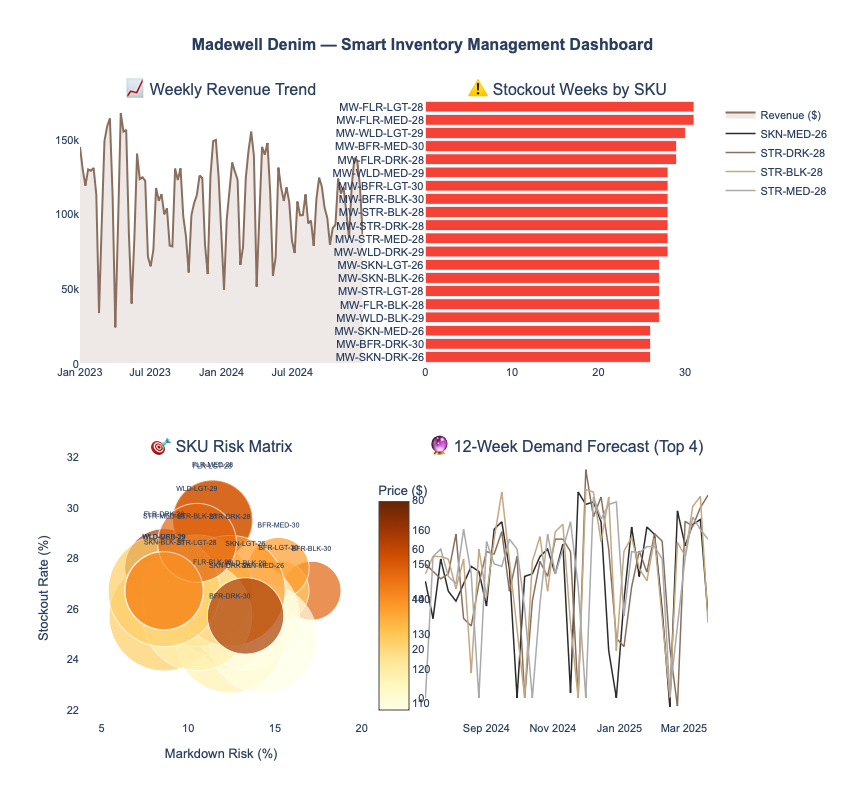

Dashboard saved to madewell_dashboard.html


In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '📈 Weekly Revenue Trend',
        '⚠️ Stockout Weeks by SKU',
        '🎯 SKU Risk Matrix',
        '🔮 12-Week Demand Forecast (Top 4)',
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.10,
)

# ── Panel 1: Weekly revenue ──────────────────────────────
weekly = df.copy()
weekly['Revenue'] = weekly['Units_Sold'] * weekly['Price_USD']
weekly_agg = weekly.groupby('Date').agg(
    Revenue=('Revenue', 'sum'),
    Units_Sold=('Units_Sold', 'sum'),
).reset_index()

fig.add_trace(go.Scatter(
    x=weekly_agg['Date'], y=weekly_agg['Revenue'],
    name='Revenue ($)', fill='tozeroy',
    line=dict(color='#8B6F5E', width=2),
    fillcolor='rgba(139,111,94,0.15)'
), row=1, col=1)

# ── Panel 2: Stockout weeks per SKU ─────────────────────
so_by_sku = df.groupby('SKU_ID')['Stockout'].sum().sort_values(ascending=True)
bar_colors = ['#F44336' if v > 25 else '#FFC107' if v > 15 else '#4CAF50'
              for v in so_by_sku.values]

fig.add_trace(go.Bar(
    x=so_by_sku.values, y=so_by_sku.index,
    orientation='h', marker_color=bar_colors,
    name='Stockout Weeks', showlegend=False
), row=1, col=2)

# ── Panel 3: Risk matrix ─────────────────────────────────
fig.add_trace(go.Scatter(
    x=sku_stats['Markdown_Rate_Pct'],
    y=sku_stats['Stockout_Rate_Pct'],
    mode='markers+text',
    text=sku_stats['SKU_ID'].str.replace('MW-', ''),
    textposition='top center',
    textfont=dict(size=7),
    marker=dict(
        size=sku_stats['Annual_Demand'] / 30,
        color=sku_stats['Price_USD'],
        colorscale='YlOrBr',
        showscale=True,
        colorbar=dict(title='Price ($)', x=0.46, len=0.4, y=0.2)
    ),
    name='SKUs', showlegend=False
), row=2, col=1)

# ── Panel 4: Forecast lines (top 4 SKUs) ────────────────
colors_fc = ['#2C2C2C', '#8B6F5E', '#C4A882', '#aaaaaa']
for j, sku in enumerate(top_skus[:4]):
    hist = df[df['SKU_ID'] == sku].set_index('Date')['Units_Sold'].iloc[-26:]
    fc   = forecast_df[forecast_df['SKU_ID'] == sku]
    fig.add_trace(go.Scatter(
        x=list(hist.index) + list(fc['Date']),
        y=list(hist.values) + list(fc['Forecast']),
        name=sku.replace('MW-', ''),
        line=dict(color=colors_fc[j], width=1.5),
    ), row=2, col=2)

# ── Layout ───────────────────────────────────────────────
fig.update_layout(
    height=800,
    title=dict(
        text='<b>Madewell Denim — Smart Inventory Management Dashboard</b>',
        x=0.5, font=dict(size=16)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
)

fig.update_xaxes(title_text='Markdown Risk (%)', row=2, col=1)
fig.update_yaxes(title_text='Stockout Rate (%)', row=2, col=1)

fig.write_html('madewell_dashboard.html')
fig.show()
print("Dashboard saved to madewell_dashboard.html")

In [24]:
weekly_agg[['Date', 'Revenue']].nlargest(5, 'Revenue')

,Date,Revenue
15,2023-04-16,167604
11,2023-03-19,164040
10,2023-03-12,158832
17,2023-04-30,156414
16,2023-04-23,155264


# Smart Inventory Management System — Madewell Denim

## Overview

This project builds a data-driven inventory management system for a fictional 
Madewell denim product line, replicating the core workflow of a retail inventory 
planning analyst. Using synthetically generated but realistic data, the system 
moves from raw demand signals to actionable reorder recommendations.

**Tools:** Python, Jupyter Notebook, pandas, scikit-learn, XGBoost, statsmodels, Plotly

---

## Business Problem

Retail inventory planning involves two competing risks:
- **Stockout risk** — running out of stock and losing sales
- **Markdown risk** — overstocking and being forced to discount

This project builds a system that forecasts demand, predicts both risks, and 
recommends optimal reorder quantities to keep inventory in balance.

---

## Project Structure

| Step | Analysis | Method |
|------|----------|--------|
| 0 | Data Generation | Synthetic SKU data with realistic seasonality |
| 1 | Demand Forecasting | Holt-Winters Exponential Smoothing (ETS) |
| 2 | Markdown Risk Prediction | XGBoost Classifier |
| 3 | Stockout Risk Prediction | XGBoost Classifier |
| 4 | Reorder Optimization | EOQ + Safety Stock + Reorder Point |
| 5 | Executive Dashboard | Interactive Plotly dashboard |

---

## Dataset

The dataset was synthetically generated to simulate 2 years of weekly sales 
data across 20 Madewell denim SKUs. SKUs span three categories (Core, Trend, 
Relaxed), four silhouettes (Straight, Skinny, Wide-Leg, Flare, Boyfriend), 
and four washes (Dark, Medium, Light, Black).

Demand curves embed realistic seasonal patterns:
- **Week 14** (early April) — spring refresh
- **Week 36** (early September) — back-to-school
- **Week 48** (late November) — holiday shopping

Trend SKUs (Wide-Leg, Flare) show +8% demand growth year-over-year. 
Skinny SKUs show a slight decline, reflecting real market trends.

---

## Key Findings

**Demand Forecasting**
- Spring (March–April) is the highest revenue period, driven by seasonal demand 
  peaking around week 14
- The Holt-Winters model captures three distinct seasonal spikes per year with 
  strong fit across all Core SKUs

**Markdown & Stockout Risk**
- `Weeks_of_Supply` is the strongest predictor of markdown risk — when a SKU 
  has more than 6 weeks of stock relative to current demand, markdown pressure builds
- `Ending_Stock` is the strongest predictor of stockout risk, with stockout 
  events concentrated during peak demand weeks
- Both models achieved ROC-AUC > 0.99, reflecting that the target variables 
  were derived from features present in the training data. In production, 
  these models would predict risk N weeks ahead using only features available 
  at that point in time

**Reorder Optimization**
- All 20 SKUs are flagged as High Stockout Risk under the baseline reorder 
  system, indicating systematic under-stocking
- EOQ analysis recommends order quantities of 87–139 units depending on SKU 
  price and velocity
- Core SKUs require significantly more safety stock (avg 42 units) than Trend 
  (30) or Relaxed (25) because higher absolute demand volume creates larger 
  absolute demand swings even at similar volatility percentages

---

## How to Run

1. Clone the repo
2. Install dependencies:

3. Open `madewell_inventory.ipynb` in Jupyter Notebook and run all cells

---

## Limitations & Next Steps

- **Synthetic data** — results reflect the patterns we built into the data 
  generator. A production version would use real POS and inventory data
- **Single-location model** — does not account for multi-store inventory 
  pooling or inter-store transfers
- **Static lead time** — assumes a fixed 4-week replenishment lead time; 
  real systems would model lead time variability
- **Next steps:** integrate real Madewell sell-through data via web scraping, 
  extend to a multi-location model, add a markdown timing recommender

---

*Part of a retail data science portfolio. See also: 
[Fishwife Tinned Seafood Brand Analysis](#) | 
[Lime Scooter Demand Forecasting](#)*